LOGISTIC REGRESSION

In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, f1_score, precision_score, recall_score, precision_recall_curve
import matplotlib.pyplot as plt

Starting Step 1: Load and Prepare Data...
Data loaded and processed. Total labeled transactions: 46564
class
0    42019
1     4545
Name: count, dtype: int64

Starting Step 2: Temporal Data Split...
Train set size: 29894
Val set size:   7829
Test set size:  8841

Starting Step 3: Feature Scaling...
Scaling complete.

Starting Step 4: Train Logistic Regression...
Model training complete.

Starting Step 5: Evaluate Model...
--- PERFORMANCE REPORT (BASELINE: LOGISTIC REGRESSION) ---

Metrics for 'Illicit' (Class 1):
  Precision: 0.1213
  Recall:    0.8235
  F1-Score:  0.2114

Overall Metrics:
  ROC AUC:   0.8551

Detailed Classification Report:
              precision    recall  f1-score   support

   Licit (0)       0.99      0.71      0.83      8433
 Illicit (1)       0.12      0.82      0.21       408

    accuracy                           0.72      8841
   macro avg       0.55      0.77      0.52      8841
weighted avg       0.95      0.72      0.80      8841

Generating Precision-Rec

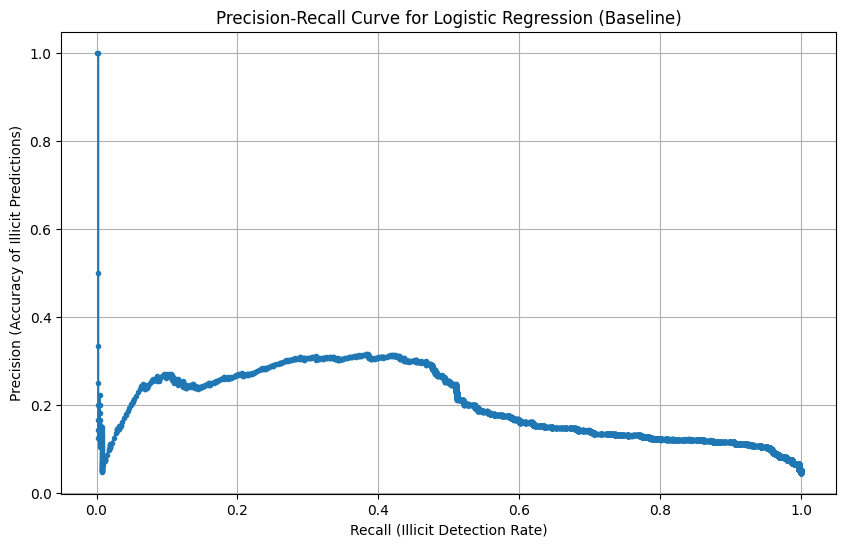

In [18]:

# --- Step 1: Load and Prepare Data ---
print("Starting Step 1: Load and Prepare Data...")

# Load the data files
try:
    df_features = pd.read_csv('/kaggle/input/elliptic/elliptic/elliptic_txs_features.csv', header=None)
    df_classes = pd.read_csv('/kaggle/input/elliptic/elliptic/elliptic_txs_classes.csv')
except FileNotFoundError:
    print("Error: CSV files not found. Please download the Elliptic dataset from Kaggle into the same directory.")
    exit()


# Col 0: txId (1)
# Col 1: timestep (1)
# Cols 2-94: Local features (93)
# Cols 95-166: Aggregated features (72)
# Total columns = 1 + 1 + 93 + 72 = 167
feature_cols = ['txId', 'timestep'] + [f'local_{i}' for i in range(93)] + [f'agg_{i}' for i in range(72)]
df_features.columns = feature_cols

# Merge features and classes
df_merged = pd.merge(df_features, df_classes, left_on='txId', right_on='txId', how='left')

# Filter out 'unknown' transactions
df_known = df_merged[df_merged['class'] != 'unknown'].copy()

# Convert labels: 'licit' (legal) -> 0, 'illicit' (fraudulent) -> 1
df_known['class'] = df_known['class'].map({'2': 0, '1': 1})

print(f"Data loaded and processed. Total labeled transactions: {len(df_known)}")
print(df_known['class'].value_counts())

# --- Step 2: Temporal Data Split ---
print("\nStarting Step 2: Temporal Data Split...")

# Separate X (features) and y (labels)
# We will use all 166 features (93 local + 72 agg + 1 timestep)
features = [col for col in df_known.columns if col not in ['txId', 'class']]
X = df_known[features]
y = df_known['class']

# Split based on project requirements
# Training Set: Time steps 1–34
train_mask = (X['timestep'] >= 1) & (X['timestep'] <= 34)
X_train, y_train = X[train_mask], y[train_mask]

# Validation Set: Time steps 35–41
val_mask = (X['timestep'] >= 35) & (X['timestep'] <= 41)
X_val, y_val = X[val_mask], y[val_mask]

# Test Set: Time steps 42–49
test_mask = (X['timestep'] >= 42) & (X['timestep'] <= 49)
X_test, y_test = X[test_mask], y[test_mask]

print(f"Train set size: {X_train.shape[0]}")
print(f"Val set size:   {X_val.shape[0]}")
print(f"Test set size:  {X_test.shape[0]}")

# --- Step 3: Feature Scaling ---
print("\nStarting Step 3: Feature Scaling...")

# Initialize StandardScaler
scaler = StandardScaler()

# FIT the scaler only on the training data
scaler.fit(X_train)

# TRANSFORM (apply) the scaler to all three sets
X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete.")

# --- Step 4: Train Logistic Regression (Handle Imbalance) ---
print("\nStarting Step 4: Train Logistic Regression...")

# Initialize the model
# Important requirement: class_weight='balanced' to perform "weighted cross-entropy"
# [cite_start]This follows the principles from the papers on rare events and imbalance [cite: 7706-7709, 11057-11060]
model = LogisticRegression(
    class_weight='balanced',  # Handle imbalance
    solver='liblinear',       # A good solver for this dataset
    max_iter=1000,            # Increase iterations to ensure convergence
    random_state=42           # For reproducible results
)

# Train the model
model.fit(X_train_scaled, y_train)

print("Model training complete.")

# --- Step 5: Evaluate Model on Test Set ---
print("\nStarting Step 5: Evaluate Model...")

# Predict on the test set
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1] # Probabilities for the positive class (illicit)

# Calculate metrics
# We focus on class '1' (illicit) as it is the rare event
precision_illicit = precision_score(y_test, y_pred, pos_label=1)
recall_illicit = recall_score(y_test, y_pred, pos_label=1)
f1_illicit = f1_score(y_test, y_pred, pos_label=1)
auc_score = roc_auc_score(y_test, y_proba)

print("--- PERFORMANCE REPORT (BASELINE: LOGISTIC REGRESSION) ---")
print(f"\nMetrics for 'Illicit' (Class 1):")
print(f"  Precision: {precision_illicit:.4f}")
print(f"  Recall:    {recall_illicit:.4f}")
print(f"  F1-Score:  {f1_illicit:.4f}")

print(f"\nOverall Metrics:")
print(f"  ROC AUC:   {auc_score:.4f}")

# Print full report
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Licit (0)', 'Illicit (1)']))

# [cite_start]Plot Precision-Recall curve, as recommended by [cite: 3093-3094, 12008]
print("Generating Precision-Recall plot...")
precision, recall, _ = precision_recall_curve(y_test, y_proba, pos_label=1)
plt.figure(figsize=(10, 6))
plt.plot(recall, precision, marker='.')
plt.title('Precision-Recall Curve for Logistic Regression (Baseline)')
plt.xlabel('Recall (Illicit Detection Rate)')
plt.ylabel('Precision (Accuracy of Illicit Predictions)')
plt.grid(True)
plt.savefig('lr_precision_recall_curve.png')
print("Plot saved to 'lr_precision_recall_curve.png'")

GCN Baseline

In [20]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 27.1 MB/s eta 0:00:0000:01


Starting Step 1: Load and Prepare Full Graph Data...
Data loaded. Total nodes: 203769

Starting Step 2: Feature Scaling and Mask Creation...
Train nodes: 29894, Val nodes: 7829, Test nodes: 8841

Starting Step 3: Create PyG Data Object...
Using device: cuda
Calculated class weights: tensor([0.5655, 4.3174], device='cuda:0')

Starting Step 4: Define GCN Model...

Starting Step 5: Training GCN Model...
Epoch 010, Train Loss: 0.3642, Val Loss: 2.6433
Early stopping at epoch 11!
Training complete. Loading best model...

Starting Step 6: Final Evaluation (Overall)...
--- PERFORMANCE REPORT (BASELINE: GCN) ---

Metrics for 'Illicit' (Class 1):
  Precision: 0.0903
  Recall:    0.6863
  F1-Score:  0.1595

Overall Metrics:
  ROC AUC:   0.7394

Detailed Classification Report:
              precision    recall  f1-score   support

   Licit (0)       0.98      0.67      0.79      8433
 Illicit (1)       0.09      0.69      0.16       408

    accuracy                           0.67      8841
   ma

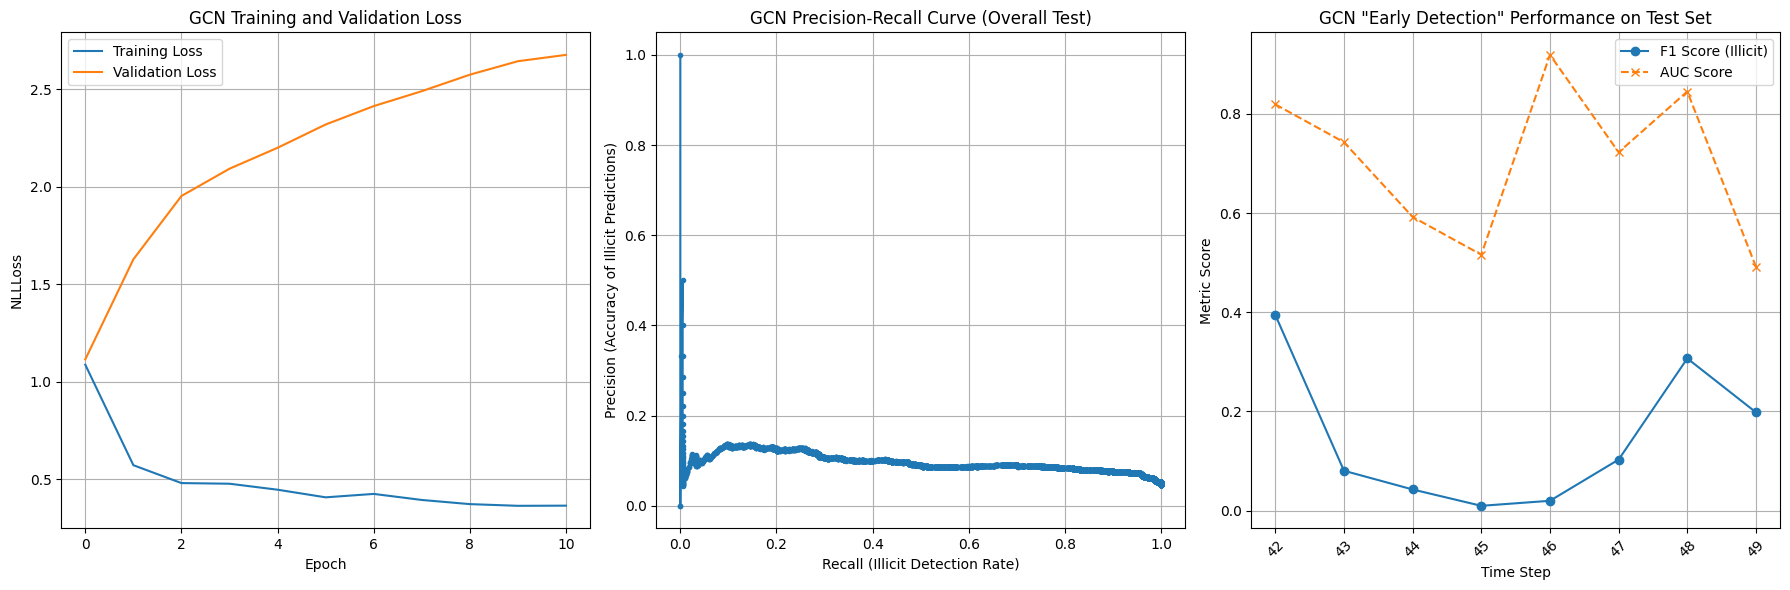

In [21]:
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, roc_auc_score, f1_score, 
    precision_score, recall_score, precision_recall_curve, log_loss
)
import matplotlib.pyplot as plt

# --- Step 1: Load and Prepare Full Graph Data ---
print("Starting Step 1: Load and Prepare Full Graph Data...")

# Load all three files
try:
    df_features = pd.read_csv('/kaggle/input/elliptic/elliptic/elliptic_txs_features.csv', header=None)
    df_classes = pd.read_csv('/kaggle/input/elliptic/elliptic/elliptic_txs_classes.csv')
    df_edgelist = pd.read_csv('/kaggle/input/elliptic/elliptic/elliptic_txs_edgelist.csv')
except FileNotFoundError:
    print("Error: CSV files not found. Please download the Elliptic dataset.")
    exit()

# Set feature column names (167 total columns)
feature_cols = ['txId', 'timestep'] + [f'local_{i}' for i in range(93)] + [f'agg_{i}' for i in range(72)]
df_features.columns = feature_cols

# Map txId to 0-based node index for PyG
all_tx_ids = df_features['txId'].unique()
tx_id_map = {tx_id: i for i, tx_id in enumerate(all_tx_ids)}

# Map edges to node indices
df_edgelist['txId1_idx'] = df_edgelist['txId1'].map(tx_id_map)
df_edgelist['txId2_idx'] = df_edgelist['txId2'].map(tx_id_map)

# Merge features and classes
df_merged = pd.merge(df_features, df_classes, on='txId', how='left')
df_merged['class'] = df_merged['class'].map({'2': 0, '1': 1, 'unknown': np.nan})

# Sort by node index (which aligns with tx_id_map)
df_merged = df_merged.set_index('txId').loc[all_tx_ids].reset_index()

print(f"Data loaded. Total nodes: {len(df_merged)}")

# --- Step 2: Feature Scaling & Create Masks ---
print("\nStarting Step 2: Feature Scaling and Mask Creation...")

# Get features (X) and labels (y)
features = [col for col in df_features.columns if col not in ['txId']] # Keep timestep
X_df = df_merged[features]
y_series = df_merged['class']

# --- Create Temporal Masks (Based on Project Spec) ---
# We create masks *before* scaling
train_mask_idx = X_df.index[
    (X_df['timestep'] >= 1) & (X_df['timestep'] <= 34) & (y_series.notna())
].values
val_mask_idx = X_df.index[
    (X_df['timestep'] >= 35) & (X_df['timestep'] <= 41) & (y_series.notna())
].values
test_mask_idx = X_df.index[
    (X_df['timestep'] >= 42) & (X_df['timestep'] <= 49) & (y_series.notna())
].values

# Scale features
# We fit the scaler ONLY on the training nodes' features
scaler = StandardScaler()
X_train_features = X_df.loc[train_mask_idx, features]
scaler.fit(X_train_features)

X_scaled = scaler.transform(X_df)

print(f"Train nodes: {len(train_mask_idx)}, Val nodes: {len(val_mask_idx)}, Test nodes: {len(test_mask_idx)}")

# --- Step 3: Create PyTorch Geometric Data Object ---
print("\nStarting Step 3: Create PyG Data Object...")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Create PyG Data object
data = Data(
    x=torch.tensor(X_scaled, dtype=torch.float).to(device),
    edge_index=torch.tensor(df_edgelist[['txId1_idx', 'txId2_idx']].values.T, dtype=torch.long).to(device),
    y=torch.tensor(y_series.values, dtype=torch.long).to(device),
    timestep=torch.tensor(X_df['timestep'].values, dtype=torch.long).to(device)
)

# Create boolean masks for training, validation, and testing
data.train_mask = torch.zeros(data.num_nodes, dtype=torch.bool).to(device)
data.train_mask[train_mask_idx] = True

data.val_mask = torch.zeros(data.num_nodes, dtype=torch.bool).to(device)
data.val_mask[val_mask_idx] = True

data.test_mask = torch.zeros(data.num_nodes, dtype=torch.bool).to(device)
data.test_mask[test_mask_idx] = True

# --- Calculate Class Weights for Imbalanced Data ---
# We must use 'data.y[data.train_mask]' to calculate weights
y_train_only = data.y[data.train_mask].cpu().numpy()
weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train_only), y=y_train_only)
class_weights = torch.tensor(weights, dtype=torch.float).to(device)

print(f"Calculated class weights: {class_weights}")

# --- Step 4: Define GCN Model ---
print("\nStarting Step 4: Define GCN Model...")

class GCN(torch.nn.Module):
    def __init__(self, num_features, hidden_dim, num_classes):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(num_features, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, num_classes)
        self.dropout = torch.nn.Dropout(p=0.5)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        
        # We output raw logits for cross_entropy, 
        # or log_softmax for NLLLoss. Let's use NLLLoss.
        return F.log_softmax(x, dim=1)

# Initialize model, optimizer, and loss function
model = GCN(
    num_features=data.num_features,
    hidden_dim=128,
    num_classes=2  # Licit (0) vs Illicit (1)
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
# Use NLLLoss because our model outputs log_softmax
# Pass the calculated class weights here
loss_fn = torch.nn.NLLLoss(weight=class_weights)

# --- Step 5: Training Loop ---
print("\nStarting Step 5: Training GCN Model...")

train_losses = []
val_losses = []
best_val_loss = float('inf')
patience = 10
patience_counter = 0

for epoch in range(200): # 200 epochs as an example
    model.train()
    optimizer.zero_grad()
    
    out = model(data)
    
    # Calculate loss ONLY on training nodes
    loss = loss_fn(out[data.train_mask], data.y[data.train_mask])
    
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    # Validation
    model.eval()
    with torch.no_grad():
        val_out = model(data)
        val_loss = loss_fn(val_out[data.val_mask], data.y[data.val_mask])
        val_losses.append(val_loss.item())

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:03d}, Train Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}")

    # Early stopping
    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        patience_counter = 0
        # Save the best model state
        torch.save(model.state_dict(), 'best_gcn_model.pth')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}!")
            break

print("Training complete. Loading best model...")
# Load the best model weights for final evaluation
model.load_state_dict(torch.load('best_gcn_model.pth'))

# --- Step 6: Final Evaluation (Overall) ---
print("\nStarting Step 6: Final Evaluation (Overall)...")
model.eval()

with torch.no_grad():
    out = model(data)
    
    # Get probabilities by applying exp() to log_softmax output
    y_proba = out.exp()[data.test_mask, 1].cpu().numpy() 
    y_pred = out.argmax(dim=1)[data.test_mask].cpu().numpy()
    y_true = data.y[data.test_mask].cpu().numpy()

# Calculate metrics
precision_illicit = precision_score(y_true, y_pred, pos_label=1)
recall_illicit = recall_score(y_true, y_pred, pos_label=1)
f1_illicit = f1_score(y_true, y_pred, pos_label=1)
auc_score = roc_auc_score(y_true, y_proba)

print("--- PERFORMANCE REPORT (BASELINE: GCN) ---")
print(f"\nMetrics for 'Illicit' (Class 1):")
print(f"  Precision: {precision_illicit:.4f}")
print(f"  Recall:    {recall_illicit:.4f}")
print(f"  F1-Score:  {f1_illicit:.4f}")
print(f"\nOverall Metrics:")
print(f"  ROC AUC:   {auc_score:.4f}")
print("\nDetailed Classification Report:")
print(classification_report(y_true, y_pred, target_names=['Licit (0)', 'Illicit (1)']))

# --- Step 7: Temporal "Early Detection" Evaluation ---
print("\nStarting Step 7: Temporal 'Early Detection' Evaluation...")

timesteps = data.timestep[data.test_mask].cpu().numpy()
test_timesteps = sorted(np.unique(timesteps))

f1_over_time = []
auc_over_time = []

for t in test_timesteps:
    t_mask = (timesteps == t)
    
    t_y_true = y_true[t_mask]
    t_y_pred = y_pred[t_mask]
    t_y_proba = y_proba[t_mask]
    
    # Calculate F1 for this timestep
    t_f1 = f1_score(t_y_true, t_y_pred, pos_label=1, zero_division=0)
    f1_over_time.append(t_f1)
    
    # Calculate AUC, handle case where only one class is present
    try:
        t_auc = roc_auc_score(t_y_true, t_y_proba)
        auc_over_time.append(t_auc)
    except ValueError:
        # This happens if a timestep has 0 illicit transactions
        auc_over_time.append(np.nan) # Use NaN for plotting

print(f"Test Timesteps: {test_timesteps}")
print(f"F1 over time:   {[round(f, 3) for f in f1_over_time]}")
print(f"AUC over time:  {[round(a, 3) if not np.isnan(a) else 'N/A' for a in auc_over_time]}")

# --- Step 8: Plotting ---
print("\nStarting Step 8: Plotting...")

plt.figure(figsize=(18, 6))

# 1. Plot Loss Curve
plt.subplot(1, 3, 1)
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('GCN Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('NLLLoss')
plt.legend()
plt.grid(True)

# 2. Plot Precision-Recall Curve (Overall Test Set)
plt.subplot(1, 3, 2)
precision, recall, _ = precision_recall_curve(y_true, y_proba, pos_label=1)
plt.plot(recall, precision, marker='.')
plt.title('GCN Precision-Recall Curve (Overall Test)')
plt.xlabel('Recall (Illicit Detection Rate)')
plt.ylabel('Precision (Accuracy of Illicit Predictions)')
plt.grid(True)

# 3. Plot F1 Score over Time (Early Detection)
plt.subplot(1, 3, 3)
plt.plot(test_timesteps, f1_over_time, marker='o', label='F1 Score (Illicit)')
# Plot AUC as well, on a secondary y-axis if desired or separate plot
plt.plot(test_timesteps, auc_over_time, marker='x', label='AUC Score', linestyle='--')
plt.title('GCN "Early Detection" Performance on Test Set')
plt.xlabel('Time Step')
plt.ylabel('Metric Score')
plt.xticks(test_timesteps, rotation=45)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('gcn_baseline_results.png')
print("All plots saved to 'gcn_baseline_results.png'")